In [18]:
# STEP 1: Import Libraries
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [19]:
# STEP 2: Load Dataset


file_name = "tested.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (418, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [20]:
# STEP 3: Understand Dataset


print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name       

In [22]:
# STEP 4: Check Target Column

if "Survived" not in df.columns:
    raise ValueError(
        "ERROR: 'Survived' column is missing. "
        "Use Titanic train.csv or a dataset containing Survived."
    )

In [24]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

# Keep only columns that actually exist
features = [col for col in features if col in df.columns]

data = df[features + ["Survived"]].copy()

print("\nSelected columns:")
print(data.columns.tolist())


Selected columns:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']


In [25]:
# STEP 6: Clean Missing Values


# Age -> replace missing values with median
if "Age" in data.columns:
    data["Age"] = data["Age"].fillna(data["Age"].median())

# Fare -> replace missing values with median
if "Fare" in data.columns:
    data["Fare"] = data["Fare"].fillna(data["Fare"].median())

# Embarked -> replace missing values with most frequent value
if "Embarked" in data.columns:
    data["Embarked"] = data["Embarked"].fillna(
        data["Embarked"].mode()[0]
    )

print("\nMissing values after cleaning:")
print(data.isnull().sum())


Missing values after cleaning:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64


In [26]:
# STEP 7: Separate X and y


X = data.drop("Survived", axis=1)
y = data["Survived"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (418, 7)
y shape: (418,)


In [27]:
# STEP 8: Encode Categorical Data
# -----------------------------

# Convert Sex and Embarked into numerical columns
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

print("\nEncoded features:")
print(X.head())

print("\nFeature names:")
print(X.columns.tolist())


Encoded features:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  34.5      0      0   7.8292         1           1           0
1       3  47.0      1      0   7.0000         0           0           1
2       2  62.0      0      0   9.6875         1           1           0
3       3  27.0      0      0   8.6625         1           0           1
4       3  22.0      1      1  12.2875         0           0           1

Feature names:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [28]:
# STEP 9: Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (334, 8)
Testing data: (84, 8)


In [29]:
# STEP 10: Feature Scaling


# Scaling is mainly required for Logistic Regression.
# We will create scaled data for Logistic Regression.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# STEP 11: LOGISTIC REGRESSION


logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(X_test_scaled)

logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [32]:
# STEP 12: DECISION TREE


tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(X_test)

tree_prob = tree_model.predict_proba(
    X_test
)[:, 1]

In [34]:
# STEP 13: RANDOM FOREST


forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

forest_pred = forest_model.predict(X_test)

forest_prob = forest_model.predict_proba(
    X_test
)[:, 1]

In [36]:
# STEP 14: MODEL EVALUATION


results = []

models = {
    "Logistic Regression": (
        logistic_pred,
        logistic_prob
    ),

    "Decision Tree": (
        tree_pred,
        tree_prob
    ),

    "Random Forest": (
        forest_pred,
        forest_prob
    )
}


for name, (pred, prob) in models.items():

    accuracy = accuracy_score(
        y_test,
        pred
    )

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        prob
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        roc_auc
    ])


In [37]:
# STEP 15: Results Table


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "ROC-AUC"
    ]
)

print("\n================ MODEL RESULTS ================")

display(
    results_df.round(4)
)


================ MODEL RESULTS ================


,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


In [38]:
# STEP 16: CLASSIFICATION REPORT

print("\n================ LOGISTIC REGRESSION ================")

print(
    classification_report(
        y_test,
        logistic_pred,
        zero_division=0
    )
)


print("\n================ DECISION TREE ================")

print(
    classification_report(
        y_test,
        tree_pred,
        zero_division=0
    )
)


print("\n================ RANDOM FOREST ================")

print(
    classification_report(
        y_test,
        forest_pred,
        zero_division=0
    )
)


================ LOGISTIC REGRESSION ================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


================ DECISION TREE ================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


================ RANDOM FOREST ================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                 

In [39]:
# STEP 17: CONFUSION MATRICES


print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, forest_pred))


Logistic Regression Confusion Matrix:
[[53  0]
 [ 0 31]]

Decision Tree Confusion Matrix:
[[53  0]
 [ 0 31]]

Random Forest Confusion Matrix:
[[53  0]
 [ 0 31]]


In [40]:
# STEP 18: RANDOM FOREST FEATURE IMPORTANCE


forest_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

forest_importance = forest_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n================ FEATURE IMPORTANCE ================")

display(
    forest_importance.round(4)
)


================ FEATURE IMPORTANCE ================


,Feature,Importance
5,Sex_male,0.8047
4,Fare,0.0681
1,Age,0.0533
3,Parch,0.0281
2,SibSp,0.0143
0,Pclass,0.0134
7,Embarked_S,0.0092
6,Embarked_Q,0.0089


In [41]:
# STEP 19: DECISION TREE FEATURE IMPORTANCE


tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

tree_importance = tree_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n================ DECISION TREE IMPORTANCE ================")

display(
    tree_importance.round(4)
)


================ DECISION TREE IMPORTANCE ================


,Feature,Importance
5,Sex_male,1.0
0,Pclass,0.0
1,Age,0.0
2,SibSp,0.0
3,Parch,0.0
4,Fare,0.0
6,Embarked_Q,0.0
7,Embarked_S,0.0


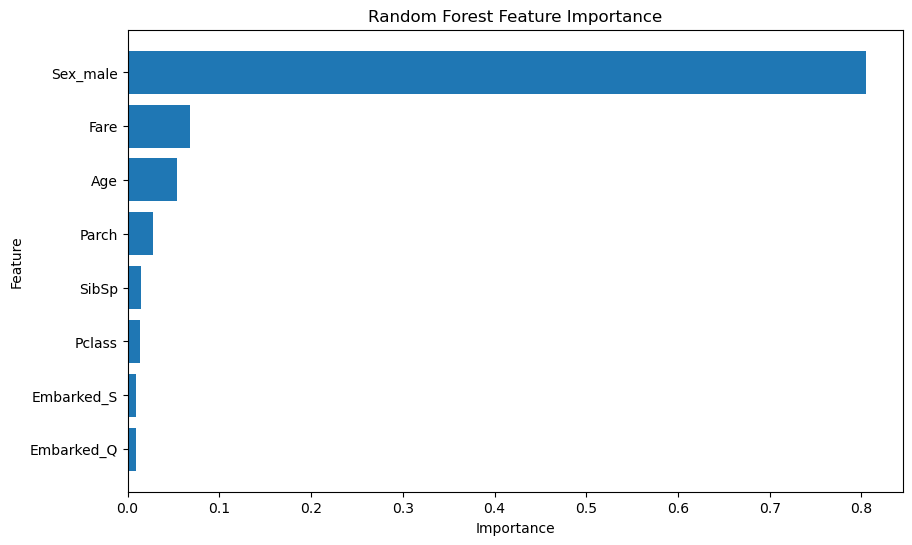

In [42]:
# STEP 20: PLOT FEATURE IMPORTANCE


plt.figure(figsize=(10, 6))

plt.barh(
    forest_importance["Feature"],
    forest_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

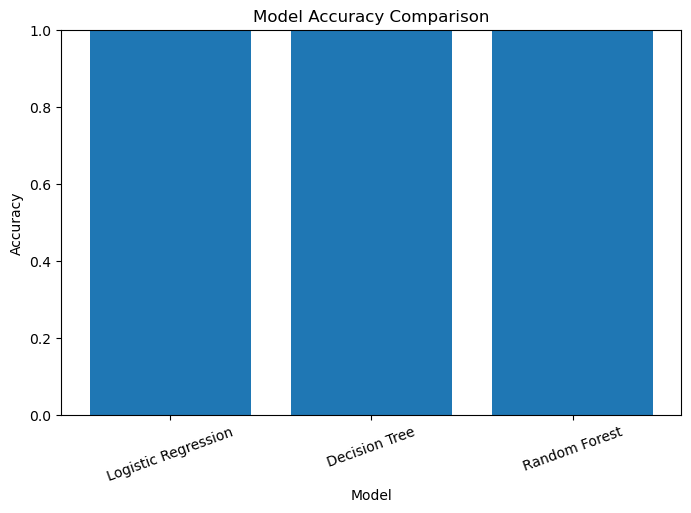

In [43]:
# STEP 21: COMPARE MODEL ACCURACY


plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

In [45]:
# STEP 22: PREDICT A NEW PASSENGER

# Example passenger:
# Pclass = 3
# Sex = male
# Age = 25
# SibSp = 0
# Parch = 0
# Fare = 10
# Embarked = S

new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": ["male"],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [10],
    "Embarked": ["S"]
})